In [1]:
import matplotlib.pyplot as plt

In [ ]:
from cea_lib.signal1D import*
from cea_lib.general import*
from cea_lib.data_loader import*
from cea_lib.output import*
from cea_lib.signal2D import*
from cea_lib.physic import*
from cea_lib.data_exporter import*

# Visualisation

In [3]:
data, labels = load_RTCEA("data/RTCEA_bimode.hdf5")

In [ ]:
atwood = create_atwood_dic(labels)
idxs = atwood[0.3]
sim = data[idxs,:,:] 
time = labels[idxs,1]   

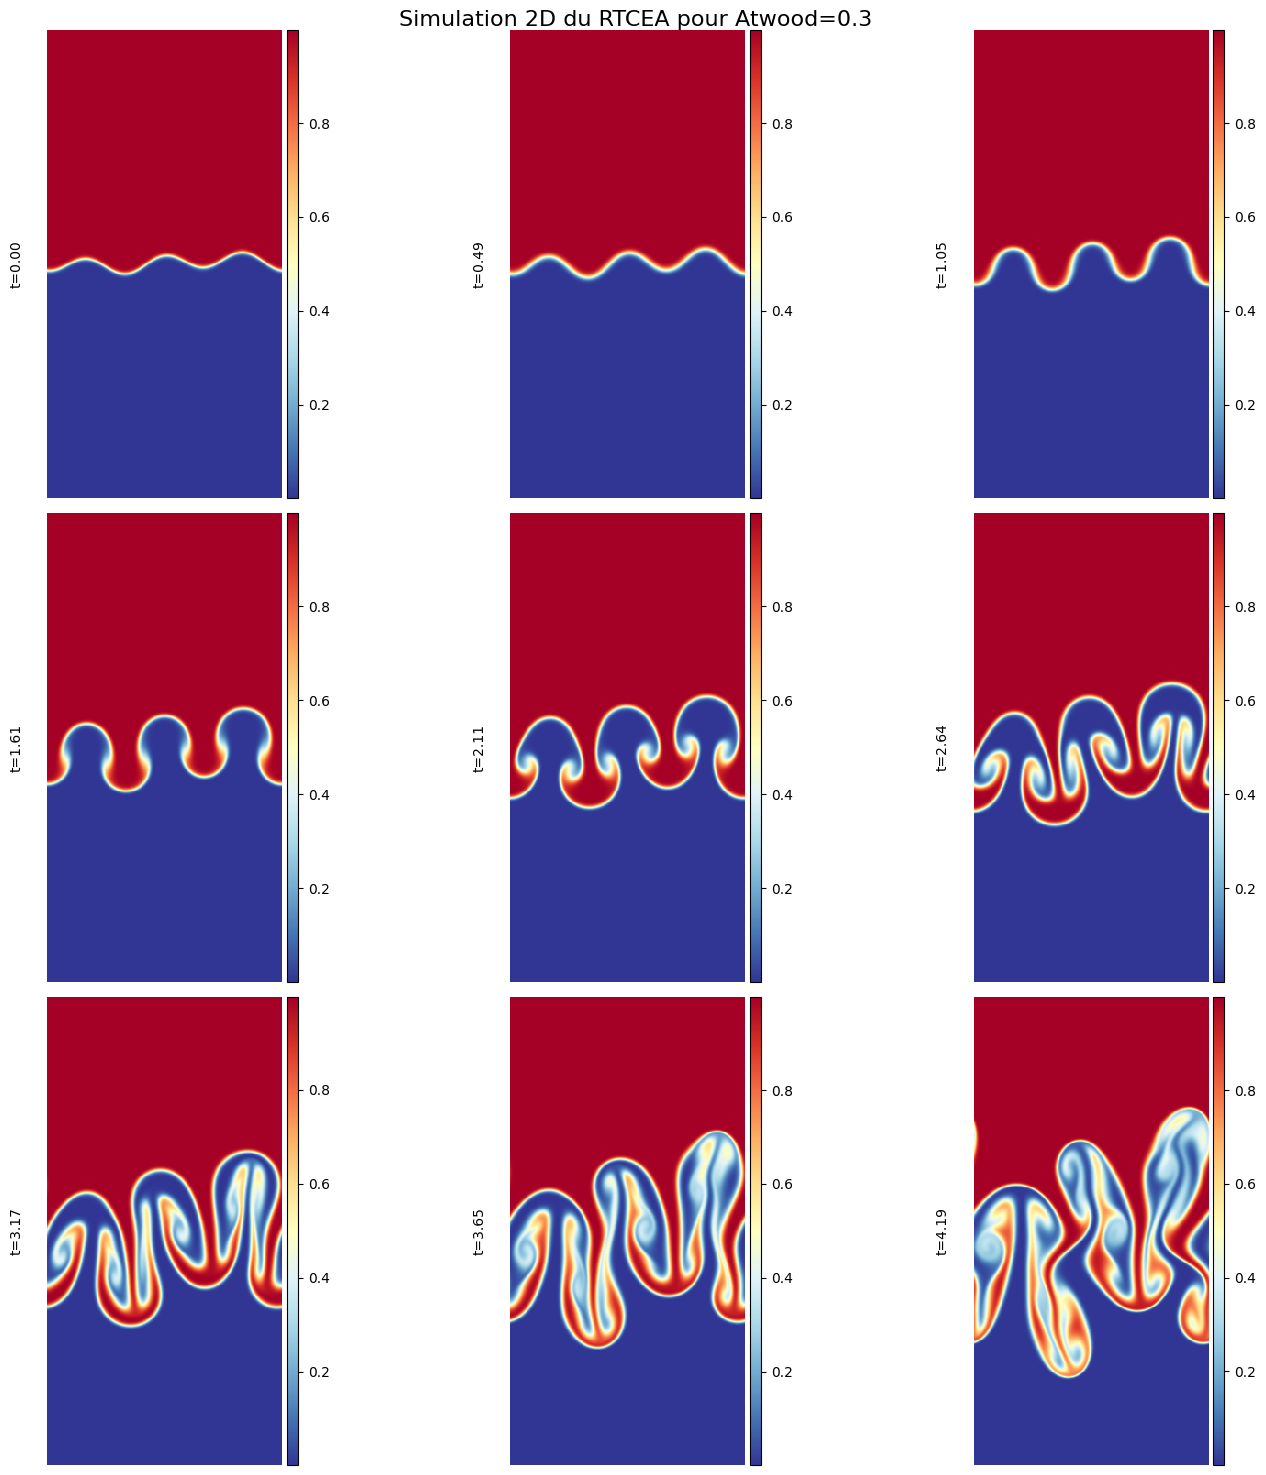

In [10]:
plot_sim_2d(sim, time, titre="Simulation 2D du RTCEA pour Atwood=0.3", save=True)

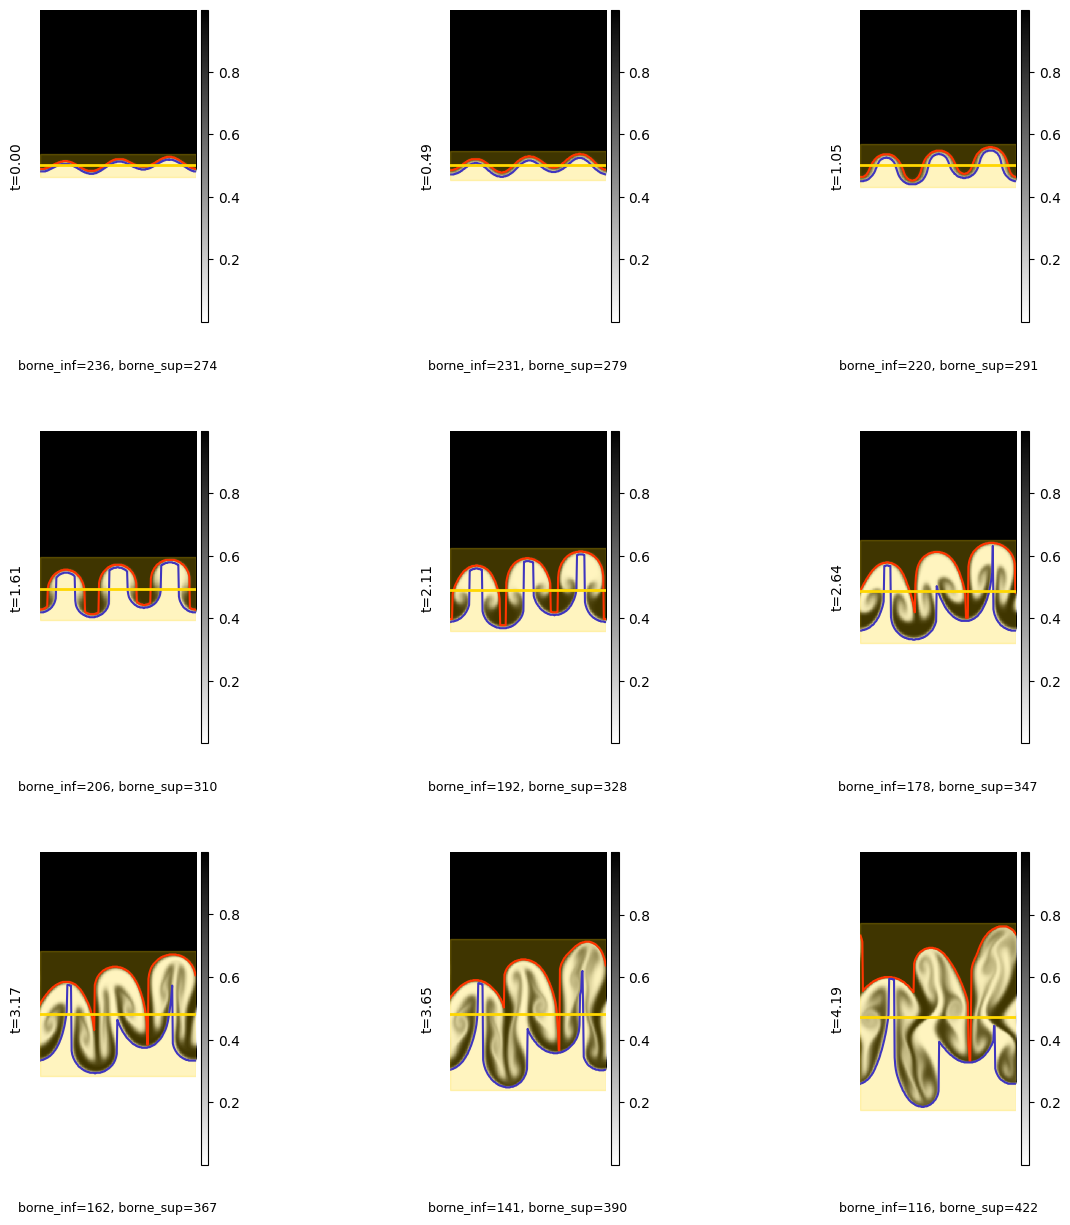

In [11]:
def plot_sim_2d_melange_info(sim, alpha_band=0.25, epsilon=0.5, marge=10):
    """
    Affiche une série de simulations 2D à différents instants, avec les bornes
    de mélange tracées colonne par colonne.

    Args:
        sim (ndarray): simulations de forme (n, h, w)
        alpha_band (float): opacité de la bande verte
        epsilon (float): seuil utilisé pour calculer les bornes de la zone de mélange
        marge (int): marge en pixels ajoutée aux bornes
    """
    plt.figure(figsize=(15, 15))
    plt.subplots_adjust(hspace=0.35)
    for i in range(9):
        nb = i * sim.shape[0] // 9
        img = sim[nb]
        imageplot(
            img,
            f"t={time[nb]:.2f}",
            [3, 3, i + 1],
            cmap='binary',
            colorbar=True,
            title_position="left"
        )
        fig = plt.gcf()
        ax = fig.axes[-2]
        h, _ = img.shape
        borne_inf, borne_sup, borne_inf_col, borne_sup_col = taille_zone_melange(
            img,
            epsilon=epsilon,
            marge=marge,
            list=True
        )

        if borne_inf is None or borne_sup is None:
            continue

        cols = np.arange(img.shape[1])
        valid_inf = ~np.isnan(borne_inf_col)
        valid_sup = ~np.isnan(borne_sup_col)

        if np.any(valid_inf):
            ax.plot(cols[valid_inf], borne_inf_col[valid_inf], color='red', linewidth=1.5, label='borne inf')
        if np.any(valid_sup):
            ax.plot(cols[valid_sup], borne_sup_col[valid_sup], color='blue', linewidth=1.5, label='borne sup')

        ax.axhspan(
            borne_inf,
            borne_sup,
            xmin=0,
            xmax=1,
            facecolor='gold',
            edgecolor='gold',
            linewidth=1.0,
            alpha=alpha_band,
            zorder=10
        )

        milieu_zone_melange = (borne_inf + borne_sup) // 2
        # ax.axhline(y=h // 2, color='white', linewidth=2)
        ax.axhline(y=milieu_zone_melange, color='gold', linewidth=2)
        ax.text(
            0.5,
            -0.12,
            f"borne_inf={borne_inf}, borne_sup={borne_sup}",
            transform=ax.transAxes,
            ha='center',
            va='top',
            fontsize=9,
            color='black'
        )
    plt.savefig("img/dataset/Verification_zone_melange.png", dpi=300)
    plt.show()


sim = normalize2d(sim)
plot_sim_2d_melange_info(sim, alpha_band=0.25, epsilon=0.1, marge=5)

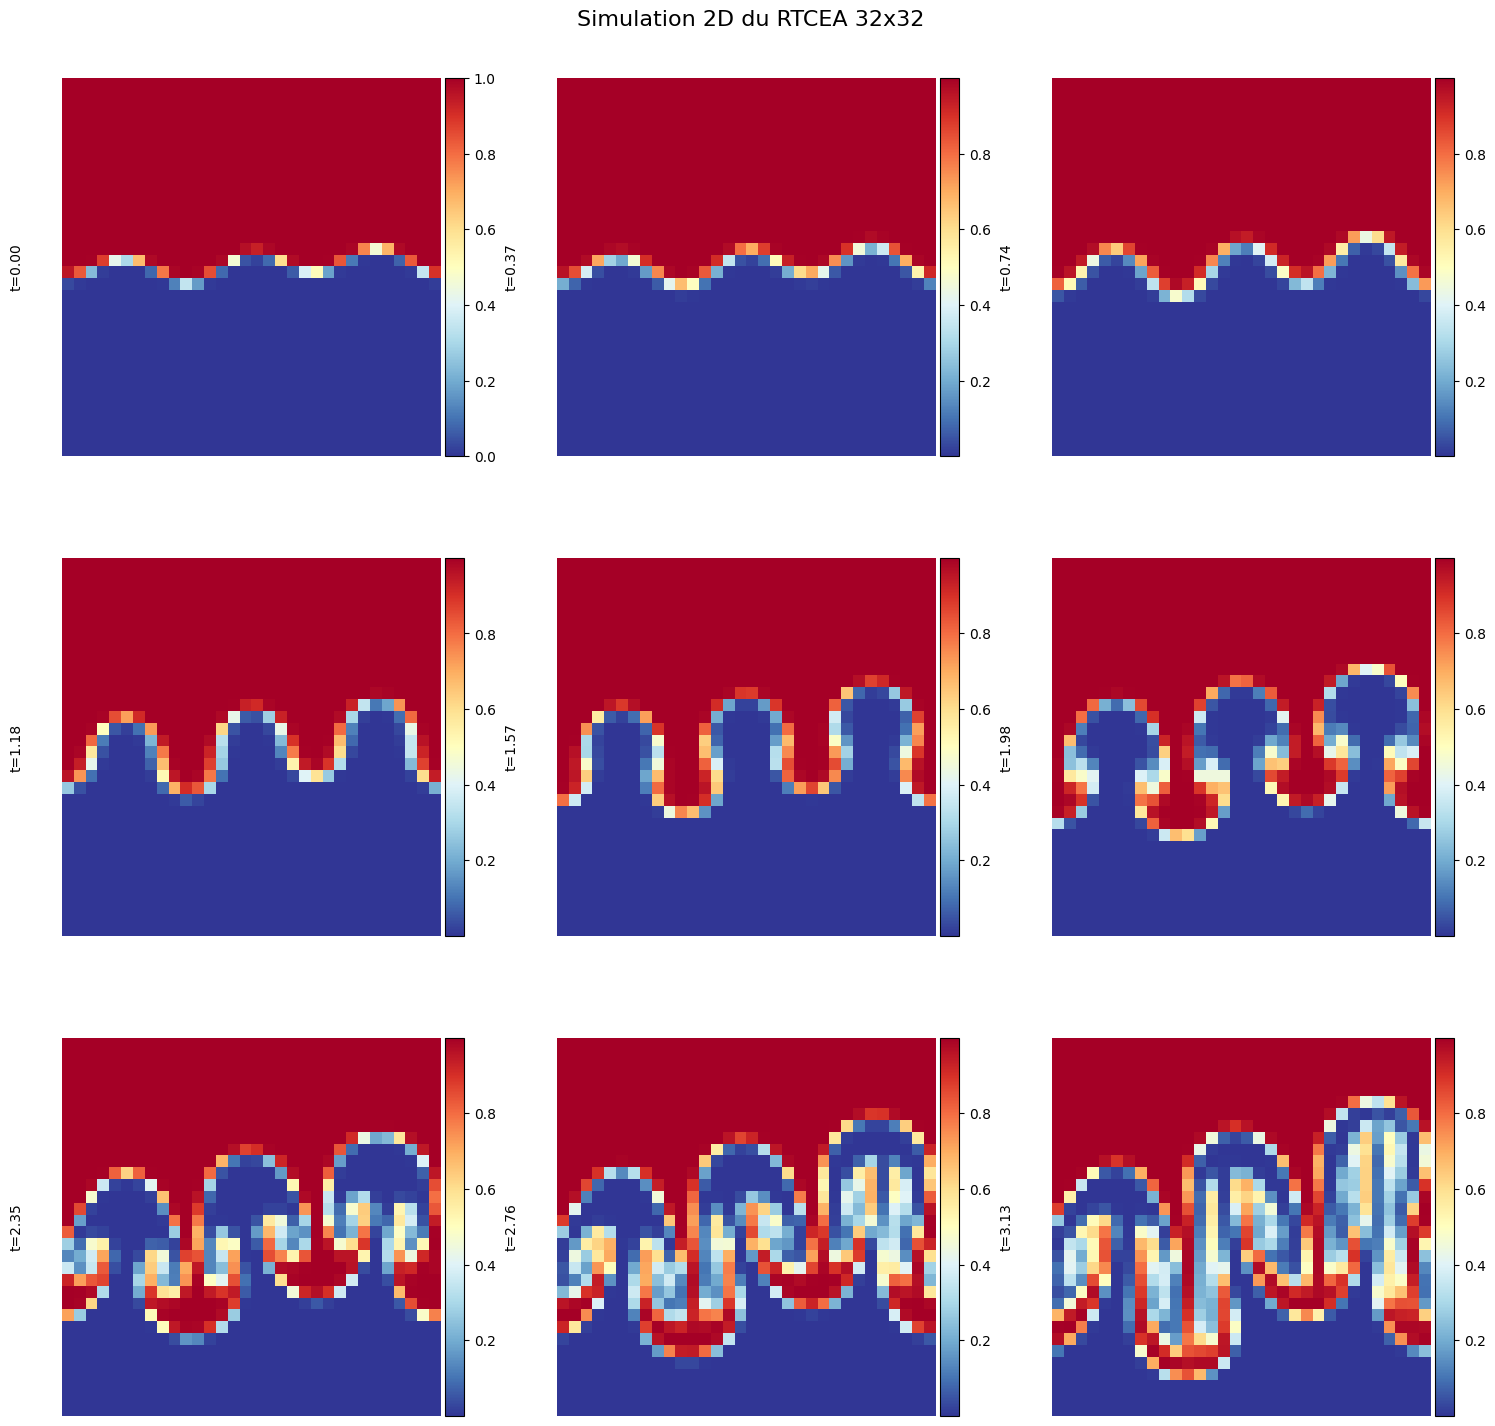

In [12]:
sim_norm, new_time = data_preprocessing(sim, time, resize=32)
plot_sim_2d(sim_norm, new_time, titre="Simulation 2D du RTCEA 32x32", save=True)

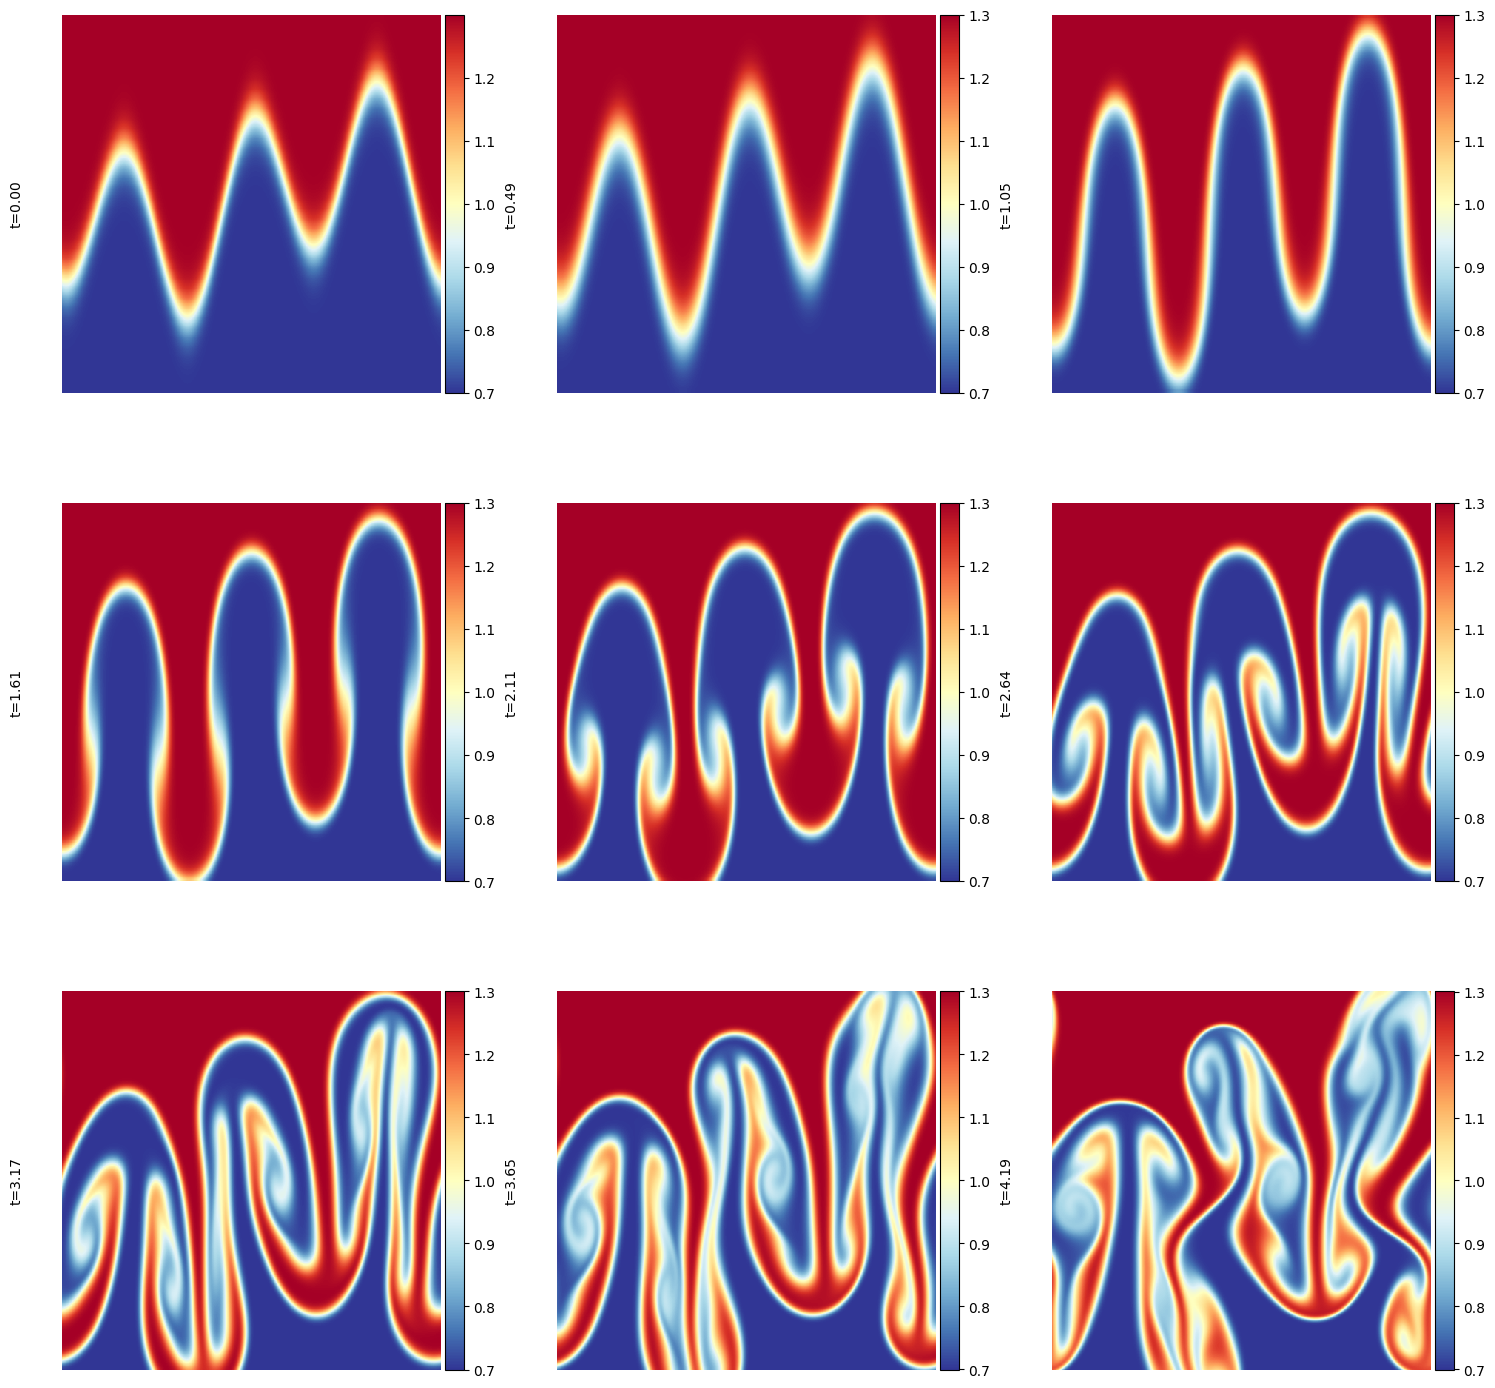

(114, 512, 512)


In [8]:
data_norm = data_normalise_2d(data, labels, marge=0.15, square=True)
atwood = create_atwood_dic(labels)

idxs = atwood[0.3]
sim2 = data_norm[idxs,:,:] 
time2 = labels[idxs,1]

plot_sim_2d(sim2, time2)
print(sim2.shape)

In [9]:
export_sim_to_jpg(sim_norm, new_time)

FileNotFoundError: [Errno 2] No such file or directory: 'datasets/RT/sim_0.jpg'